Unit 6 Unsupervised Learning

Harriet Tidwell

Problem 1 Preprocessing (Convert Income to Numeric)

In [1]:
# To get rid of warnings
%env OMP_NUM_THREADS=1

env: OMP_NUM_THREADS=1


In [2]:
# Import needed functions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
# Read dataset
mall = pd.read_csv("mallcustomers.csv")

In [4]:
# Preview data types
mall.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CustomerID     200 non-null    int64
 1   Gender         200 non-null    str  
 2   Age            200 non-null    int64
 3   Income         200 non-null    str  
 4   SpendingScore  200 non-null    int64
dtypes: int64(3), str(2)
memory usage: 10.9 KB


In [5]:
# Clean Income: remove commas and USD
mall["Income"] = mall["Income"].str.replace(",", "")
mall["Income"] = mall["Income"].str.replace(" USD", "")
mall["Income"] = mall["Income"].astype(float)

mall.head()

,CustomerID,Gender,Age,Income,SpendingScore
0,1,Male,19,15000.0,39
1,2,Male,21,15000.0,81
2,3,Female,20,16000.0,6
3,4,Female,23,16000.0,77
4,5,Female,31,17000.0,40


Problem 2 Keep Only Needed Features

In [6]:
mall_cluster = mall[["Income", "SpendingScore", "Gender", "Age"]]
mall_cluster.head()

,Income,SpendingScore,Gender,Age
0,15000.0,39,Male,19
1,15000.0,81,Male,21
2,16000.0,6,Female,20
3,16000.0,77,Female,23
4,17000.0,40,Female,31


Problem 3 Summary Statistics + Z-Score Normalization

In [7]:
# Summary Statistics
mall_cluster[["Income", "SpendingScore"]].describe()

,Income,SpendingScore
count,200.000000,200.000000
mean,60560.000000,50.200000
std,26264.721165,25.823522
min,15000.000000,1.000000
25%,41500.000000,34.750000
50%,61500.000000,50.000000
75%,78000.000000,73.000000
max,137000.000000,99.000000


In [8]:
# Z-Score normalization
scaler = StandardScaler()
scaled_features = scaler.fit_transform(mall_cluster[["Income", "SpendingScore"]])

mall_scaled = pd.DataFrame(scaled_features, columns=["Income_scaled", "Spending_scaled"])
mall_scaled["Gender"] = mall_cluster["Gender"]
mall_scaled["Age"] = mall_cluster["Age"]

mall_scaled.head()

,Income_scaled,Spending_scaled,Gender,Age
0,-1.738999,-0.434801,Male,19
1,-1.738999,1.195704,Male,21
2,-1.700830,-1.715913,Female,20
3,-1.700830,1.040418,Female,23
4,-1.662660,-0.395980,Female,31


Problem 4 Elbow Method + K-Means Clustering

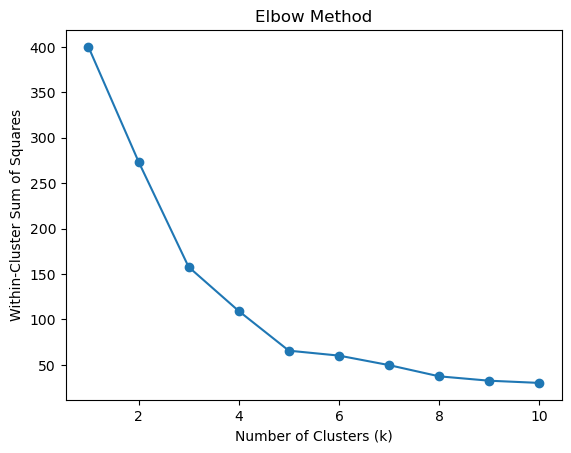

In [9]:
# Elbow Method
X = mall_scaled[["Income_scaled", "Spending_scaled"]]

wss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    wss.append(km.inertia_)

plt.plot(range(1, 11), wss, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares")
plt.title("Elbow Method")
plt.show()

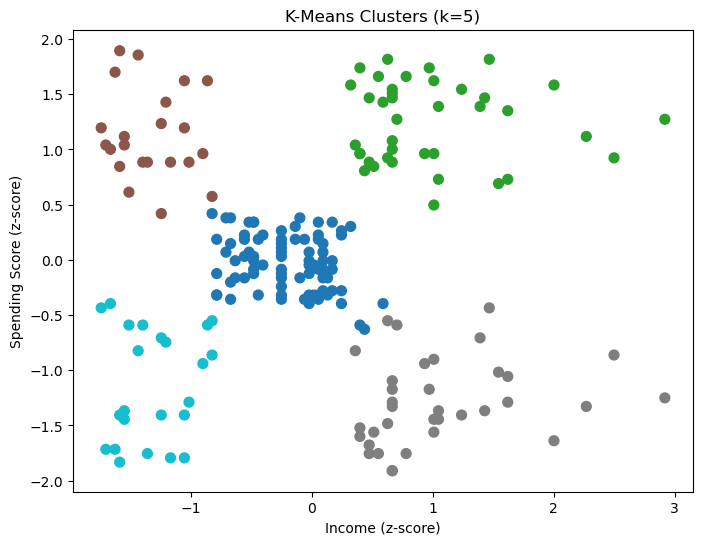

array([[-0.20091257, -0.02645617],
       [ 0.99158305,  1.23950275],
       [-1.32954532,  1.13217788],
       [ 1.05500302, -1.28443907],
       [-1.30751869, -1.13696536]])

In [10]:
# Final K-Means
k = 5

km_final = KMeans(n_clusters=k, random_state=42)
mall_scaled["Cluster"] = km_final.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(
    mall_scaled["Income_scaled"],
    mall_scaled["Spending_scaled"],
    c=mall_scaled["Cluster"], 
    cmap="tab10",
    s=50
)
plt.xlabel("Income (z-score)")
plt.ylabel("Spending Score (z-score)")
plt.title(f"K-Means Clusters (k={k})")
plt.show()

km_final.cluster_centers_
        

Problem 5 Evaluating the Clusters

In [11]:
# Create dummy variables Male and Female
mall_scaled["Male"] = (mall_scaled["Gender"] == "Male").astype(int)
mall_scaled["Female"] = (mall_scaled["Gender"] == "Female").astype(int)

gender_dist = mall_scaled.groupby("Cluster")[["Male", "Female"]].mean()
age_dist = mall_scaled.groupby("Cluster")["Age"].mean()

gender_dist, age_dist

(             Male    Female
 Cluster                    
 0        0.407407  0.592593
 1        0.461538  0.538462
 2        0.409091  0.590909
 3        0.542857  0.457143
 4        0.391304  0.608696,
 Cluster
 0    42.716049
 1    32.692308
 2    25.272727
 3    41.114286
 4    45.217391
 Name: Age, dtype: float64)

### Naming Cluster and Interpretation Based on Demographics

Using the demographic summaries:

- **Occasional Visitors (Cluster 0)**  
  Slightly below-average income, average spending. Mixed demographics, irregular mall engagement.

- **Premium Loyalists (Cluster 1)**  
  High income, very high spending. Skew female, mid-career.

- **Value-Seeking Enthusiasts (Cluster 2)**  
  Low income, high spending. Younger, respond strongly to promotions.

- **High-Income Minimalists (Cluster 3)**  
  Very high income, very low spending. Skew male, slightly older.

- **Budget Shoppers (Cluster 4)**  
  Very low income, very low spending. Mixed gender, lower engagement.